In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content
!wget -q --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip
!unzip -q UCF101TrainTestSplits-RecognitionTask.zip
!ls /content/ucfTrainTestlist

/content
classInd.txt	testlist02.txt	trainlist01.txt  trainlist03.txt
testlist01.txt	testlist03.txt	trainlist02.txt


In [6]:
%cd /content
!git clone https://github.com/miirage-exe/video-action-recognition.git
%cd video-action-recognition
!git checkout -b frank/multimodal-extension

/content
Cloning into 'video-action-recognition'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 0), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 1.02 MiB | 49.72 MiB/s, done.
/content/video-action-recognition
Switched to a new branch 'frank/multimodal-extension'


In [7]:
import os

if os.path.exists("/content/video-action-recognition"):
    %cd /content/video-action-recognition
else:
    print("The repository does not exist.")

!git checkout frank/multimodal-extension
!git pull origin frank/multimodal-extension
!git log --oneline -5

/content/video-action-recognition
Already on 'frank/multimodal-extension'
fatal: couldn't find remote ref frank/multimodal-extension
e584aab (HEAD -> frank/multimodal-extension, origin/main, origin/HEAD, main) add assignement and usefull links
5d53987 first-version-by-Lei
d80b712 init: add README


In [8]:
# Step 1: Library Import
from pathlib import Path
from collections import Counter, defaultdict
import re, random

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from tqdm import tqdm

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# path
DATA_DIR  = Path("/content/drive/MyDrive/datasets/UCF-101")
SPLIT_DIR = Path("/content/ucfTrainTestlist")

# hyperparameters
NUM_FRAMES = 8
IMAGE_SIZE = 112
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
SPLIT_ID = 1
VAL_RATIO = 0.2

Using: cuda
GPU: NVIDIA A100-SXM4-80GB


In [9]:
# Step 2: Data Directory
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Number of classes: {len(class_names)}")
print(f"First 5 Classes: {class_names[:5]}")

video_files = list(DATA_DIR.rglob("*.avi"))
print(f"Number of video files: {len(video_files)}")

Number of classes: 101
First 5 Classes: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']
Number of video files: 13336


Number of classes: 101
First 5 Classes: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']
Number of video files: 13336
Sample video: /content/drive/MyDrive/datasets/UCF-101/VolleyballSpiking/v_VolleyballSpiking_g01_c01.avi
frame count, fps, width, height: 93, 29.97002997002997, 320, 240


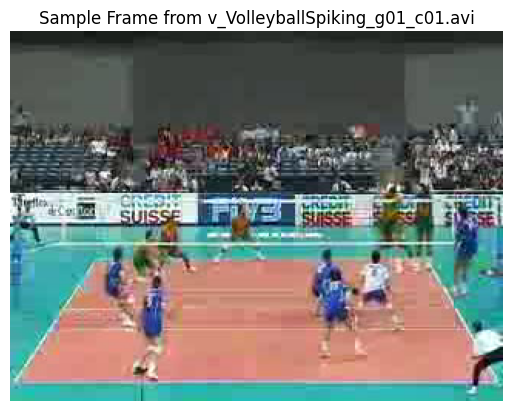

In [10]:
# Step 3 Document understanding + visualization
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Number of classes: {len(class_names)}")
print(f"First 5 Classes: {class_names[:5]}")

video_files = list(DATA_DIR.rglob("*.avi"))
print(f"Number of video files: {len(video_files)}")

sample_video_path = video_files[0]
cap = cv2.VideoCapture(str(sample_video_path))

if not cap.isOpened():
    raise IOError(f"Cannot open video file: {sample_video_path}")

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps         = cap.get(cv2.CAP_PROP_FPS)
width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Sample video: {sample_video_path}")
print(f"frame count, fps, width, height: {frame_count}, {fps}, {width}, {height}")

success, frame = cap.read()
if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.title(f"Sample Frame from {sample_video_path.name}")
    plt.show()
cap.release()

In [11]:
# Step 4: Manifest
NUM_SELECTED_CLASSES = len(class_names)
selected_classes = class_names[:NUM_SELECTED_CLASSES]
print(f"Number of classes used for training: {NUM_SELECTED_CLASSES}")

def build_manifest_from_split(split_dir, data_dir, selected_classes, method):
    if method == "train":
        split_file = split_dir / f"trainlist{SPLIT_ID:02d}.txt"
    elif method == "test":
        split_file = split_dir / f"testlist{SPLIT_ID:02d}.txt"
    else:
        raise ValueError("method must be 'train' or 'test'")

    selected_set   = set(selected_classes)
    class_to_label = {c: i for i, c in enumerate(selected_classes)}
    manifest = []

    with open(split_file, "r") as f:
        for line in f:
            relative_path = line.strip().split()[0]
            class_name    = relative_path.split("/")[0]
            if class_name not in selected_set:
                continue
            full_video_path = data_dir / relative_path
            label = class_to_label[class_name]
            if full_video_path.exists():
                manifest.append((full_video_path, label, class_name))

    return manifest

train_files = build_manifest_from_split(SPLIT_DIR, DATA_DIR, selected_classes, method="train")
test_files  = build_manifest_from_split(SPLIT_DIR, DATA_DIR, selected_classes, method="test")
print(f"Train manifest: {len(train_files)} videos")
print(f"Test manifest:  {len(test_files)} videos")

Number of classes used for training: 101
Train manifest: 9537 videos
Test manifest:  3783 videos


In [12]:
# Step 5: Train/Val Split
def extract_group_id(video_path):
    match = re.search(r'g\d+', Path(video_path).name)
    return match.group(0) if match else None

def split_train_val_by_group(train_files, val_ratio, seed):
    grouped_videos = defaultdict(list)
    for video in train_files:
        video_path, label, class_name = video
        group_id = extract_group_id(video_path)
        group_key = (class_name, group_id)
        grouped_videos[group_key].append(video)

    group_keys = list(grouped_videos.keys())
    rng = random.Random(seed)
    rng.shuffle(group_keys)

    num_val_groups = max(1, int(len(group_keys) * val_ratio))
    val_group_keys = set(group_keys[:num_val_groups])

    train_set, val_set = [], []
    for group_key, videos in grouped_videos.items():
        if group_key in val_group_keys:
            val_set.extend(videos)
        else:
            train_set.extend(videos)

    return train_set, val_set

train_set, val_set = split_train_val_by_group(train_files, VAL_RATIO, seed=42)
print(f"Train: {len(train_set)} videos")
print(f"Val:   {len(val_set)} videos")
print(f"Test:  {len(test_files)} videos")

Train: 7611 videos
Val:   1926 videos
Test:  3783 videos


Sample count by split:
     train: 7611 videos
validation: 1926 videos
      test: 3783 videos

Class distribution summary:
Classes: 101
Minimum videos per class: 100
Maximum videos per class: 167
Mean videos per class: 131.88
Median videos per class: 131.00

Classes with smallest and largest sample counts:
class_name                        train      val     test    total
------------------------------------------------------------------
Skijet                               48       24       28      100
TaiChi                               52       20       28      100
PullUps                              48       24       28      100
PlayingViolin                        64        8       28      100
BreastStroke                         73        0       28      101
PushUps                              56       16       30      102
UnevenBars                           56       20       28      104
PlayingPiano                         56       21       28      105
BalanceBeam          

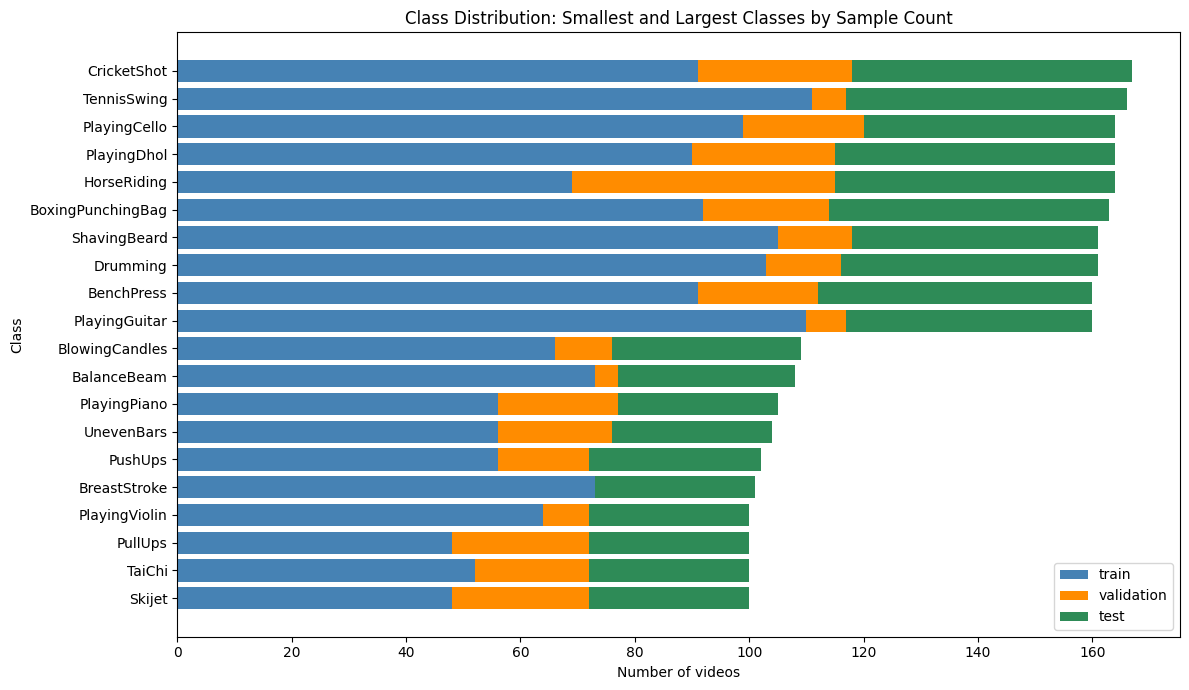

In [13]:
# Step 6: Analyze Data Split

def count_by_class(samples):
    """Count the number of videos for each class in a split."""
    return Counter(class_name for _, _, class_name in samples)


def groups_by_split(samples):
    """Return class-level group keys to check leakage between splits."""
    group_keys = set()
    for video_path, _, class_name in samples:
        group_id = extract_group_id(video_path)
        group_keys.add((class_name, group_id))
    return group_keys


def select_extreme_indices(values, top_k):
    """Return unique indices from the low and high ends of a sorted array."""
    sorted_indices = np.argsort(values)
    candidate_indices = np.concatenate([sorted_indices[:top_k], sorted_indices[-top_k:]])
    return np.array(list(dict.fromkeys(candidate_indices.tolist())))


def print_distribution_table(indices, class_names, distribution_matrix):
    header = f"{'class_name':<30} {'train':>8} {'val':>8} {'test':>8} {'total':>8}"
    print(header)
    print("-" * len(header))
    for idx in indices:
        train_count = distribution_matrix[0, idx]
        val_count = distribution_matrix[1, idx]
        test_count = distribution_matrix[2, idx]
        total_count = train_count + val_count + test_count
        print(f"{class_names[idx]:<30} {train_count:>8} {val_count:>8} {test_count:>8} {total_count:>8}")


split_samples = {
    "train": train_set,
    "validation": val_set,
    "test": test_files,
}

print("Sample count by split:")
for split_name, samples in split_samples.items():
    print(f"{split_name:>10}: {len(samples)} videos")

class_distribution = {
    split_name: count_by_class(samples)
    for split_name, samples in split_samples.items()
}

distribution_matrix = np.array([
    [class_distribution["train"].get(class_name, 0) for class_name in selected_classes],
    [class_distribution["validation"].get(class_name, 0) for class_name in selected_classes],
    [class_distribution["test"].get(class_name, 0) for class_name in selected_classes],
])

total_counts = distribution_matrix.sum(axis=0)
summary_indices = select_extreme_indices(total_counts, top_k=min(10, len(selected_classes)))

print("\nClass distribution summary:")
print(f"Classes: {len(selected_classes)}")
print(f"Minimum videos per class: {total_counts.min()}")
print(f"Maximum videos per class: {total_counts.max()}")
print(f"Mean videos per class: {total_counts.mean():.2f}")
print(f"Median videos per class: {np.median(total_counts):.2f}")
print("\nClasses with smallest and largest sample counts:")
print_distribution_table(summary_indices, selected_classes, distribution_matrix)

print("\nMissing classes by split:")
for split_name, distribution in class_distribution.items():
    missing_classes = [
        class_name
        for class_name in selected_classes
        if distribution.get(class_name, 0) == 0
    ]
    print(f"{split_name:>10}: {missing_classes if missing_classes else 'none'}")

print("\nGroup overlap check:")
group_sets = {
    split_name: groups_by_split(samples)
    for split_name, samples in split_samples.items()
}

overlap_pairs = [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
]

for left, right in overlap_pairs:
    overlap = group_sets[left] & group_sets[right]
    if overlap:
        print(f"WARNING: {left} / {right} overlap: {len(overlap)} class-group pairs")
        print(sorted(overlap)[:10])
    else:
        print(f"{left:>10} / {right:<10}: no group overlap")

plot_indices = summary_indices
plot_classes = [selected_classes[i] for i in plot_indices]
plot_train = distribution_matrix[0, plot_indices]
plot_val = distribution_matrix[1, plot_indices]
plot_test = distribution_matrix[2, plot_indices]

y = np.arange(len(plot_classes))
plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(y, plot_train, label="train", color="steelblue")
plt.barh(y, plot_val, left=plot_train, label="validation", color="darkorange")
plt.barh(y, plot_test, left=plot_train + plot_val, label="test", color="seagreen")
plt.yticks(y, plot_classes)
plt.xlabel("Number of videos")
plt.ylabel("Class")
plt.title("Class Distribution: Smallest and Largest Classes by Sample Count")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Step 7: Video Loading
def load_video_clip(video_path, num_frames, img_size):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open video file: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < num_frames:
        raise ValueError(f"Video has only {total_frames} frames.")

    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        if not success:
            if frames:
                frames.append(frames[-1].copy())
            continue
        frame_rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_resized = cv2.resize(frame_rgb, (img_size, img_size))
        frame         = frame_resized.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()
    if len(frames) == 0:
        raise ValueError(f"Could not read any frames from: {video_path}")
    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    clip = np.stack(frames, axis=0)
    clip = np.transpose(clip, (3, 0, 1, 2))
    return torch.from_numpy(clip)

sample_clip = load_video_clip(train_set[0][0], NUM_FRAMES, IMAGE_SIZE)
print(f"Clip shape: {sample_clip.shape}")

Clip shape: torch.Size([3, 8, 112, 112])


In [15]:
# Step 8: Dataset & DataLoader
class VideoDataSet(Dataset):
    def __init__(self, samples, num_frames, img_size):
        self.samples = samples
        self.num_frames = num_frames
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label, class_name = self.samples[idx]
        clip = load_video_clip(video_path, self.num_frames, self.img_size)
        label = torch.tensor(label, dtype=torch.long)
        return clip, label, str(video_path), class_name

train_dataset = VideoDataSet(train_set, NUM_FRAMES, IMAGE_SIZE)
val_dataset   = VideoDataSet(val_set,   NUM_FRAMES, IMAGE_SIZE)
test_dataset  = VideoDataSet(test_files, NUM_FRAMES, IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# verify
clips, labels, _, _ = next(iter(train_loader))
print(f"Batch shape: {clips.shape}")
print(f"Labels shape: {labels.shape}")

Batch shape: torch.Size([16, 3, 8, 112, 112])
Labels shape: torch.Size([16])


In [16]:
# Step 9: Frame-level CNN Model
class FrameLevelCNN(nn.Module):
    def __init__(self, num_classes):
        super(FrameLevelCNN, self).__init__()
        self.cnn = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Linear(self.cnn.fc.in_features, num_classes)

    def forward(self, x):
        batch_size, channels, num_frames, height, width = x.shape
        x = x.permute(0, 2, 1, 3, 4)
        x = x.reshape(batch_size * num_frames, channels, height, width)
        frame_outputs = self.cnn(x)
        frame_outputs = frame_outputs.reshape(batch_size, num_frames, -1)
        video_outputs = frame_outputs.mean(dim=1)
        return video_outputs

model = FrameLevelCNN(num_classes=NUM_SELECTED_CLASSES).to(device)

# verify
clips, labels, _, _ = next(iter(train_loader))
outputs = model(clips.to(device))
print(f"Input shape:  {clips.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Device: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]


Input shape:  torch.Size([16, 3, 8, 112, 112])
Output shape: torch.Size([16, 101])
Device: cuda:0


In [17]:
# Step 10: Train Frame-level CNN
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for clips, labels, _, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} Train"):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(clips)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * labels.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

    # Val
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for clips, labels, _, _ in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} Val"):
            clips, labels = clips.to(device), labels.to(device)
            outputs = model(clips)
            loss = criterion(outputs, labels)
            val_loss    += loss.item() * labels.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total
    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

# save
torch.save(model.state_dict(), "/content/drive/MyDrive/datasets/frame_cnn.pth")
print("Saved!")

Epoch 1/10 Val: 100%|██████████| 121/121 [16:20<00:00,  8.11s/it]


Epoch 1/10 | Train Loss: 3.0075 Acc: 0.2852 | Val Loss: 3.2323 Acc: 0.2622


Epoch 2/10 Val: 100%|██████████| 121/121 [00:57<00:00,  2.10it/s]


Epoch 2/10 | Train Loss: 1.3165 Acc: 0.6349 | Val Loss: 3.3869 Acc: 0.3027


Epoch 3/10 Val: 100%|██████████| 121/121 [00:57<00:00,  2.10it/s]


...

Epoch 8/10 | Train Loss: 0.2427 Acc: 0.9277 | Val Loss: 3.9167 Acc: 0.3479


Epoch 9/10 Val: 100%|██████████| 121/121 [00:58<00:00,  2.08it/s]


Epoch 9/10 | Train Loss: 0.1112 Acc: 0.9662 | Val Loss: 3.7702 Acc: 0.4107


Epoch 10/10 Val: 100%|██████████| 121/121 [00:57<00:00,  2.11it/s]


Epoch 10/10 | Train Loss: 0.1305 Acc: 0.9612 | Val Loss: 4.1021 Acc: 0.3801
Saved!


In [18]:
# Step 11: Evaluate Frame-level CNN
model.eval()
all_labels, all_predictions = [], []

with torch.no_grad():
    for clips, labels, _, _ in tqdm(test_loader, desc="Testing Frame-level CNN"):
        clips, labels = clips.to(device), labels.to(device)
        outputs = model(clips)
        predictions = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

all_labels      = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_acc = (all_predictions == all_labels).mean()
print(f"Frame-level CNN Test Accuracy: {test_acc:.4f}")

frame_eval_per_class_acc = []
for class_idx in range(len(selected_classes)):
    class_mask = all_labels == class_idx
    class_acc  = np.nan if class_mask.sum() == 0 else (all_predictions[class_mask] == all_labels[class_mask]).mean()
    frame_eval_per_class_acc.append(class_acc)

frame_eval_per_class_acc = np.array(frame_eval_per_class_acc)
print(f"Mean per-class accuracy: {np.nanmean(frame_eval_per_class_acc):.4f}")
print(f"Min per-class accuracy:  {np.nanmin(frame_eval_per_class_acc):.4f}")
print(f"Max per-class accuracy:  {np.nanmax(frame_eval_per_class_acc):.4f}")

Testing Frame-level CNN: 100%|██████████| 237/237 [33:09<00:00,  8.40s/it]

Frame-level CNN Test Accuracy: 0.4311
Mean per-class accuracy: 0.4323
Min per-class accuracy:  0.0000
Max per-class accuracy:  1.0000


Class                            Accuracy
-------------------------------------------
JugglingBalls                      0.0000
HandstandWalking                   0.0000
SoccerJuggling                     0.0000
ShavingBeard                       0.0000
WallPushups                        0.0000
PlayingCello                       0.0227
CricketBowling                     0.0278
TableTennisShot                    0.0513
JumpingJack                        0.0541
RopeClimbing                       0.0588
IceDancing                         0.8261
HorseRace                          0.8286
SoccerPenalty                      0.8293
Surfing                            0.8485
StillRings                         0.8750
UnevenBars                         0.8929
Bowling                            0.9302
BasketballDunk                     0.9459
BreastStroke                       1.0000
Billiards                          1.0000


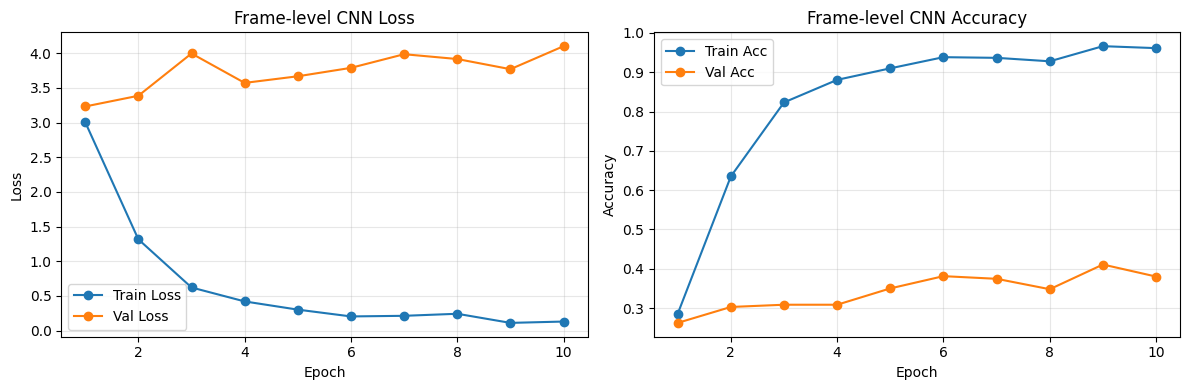

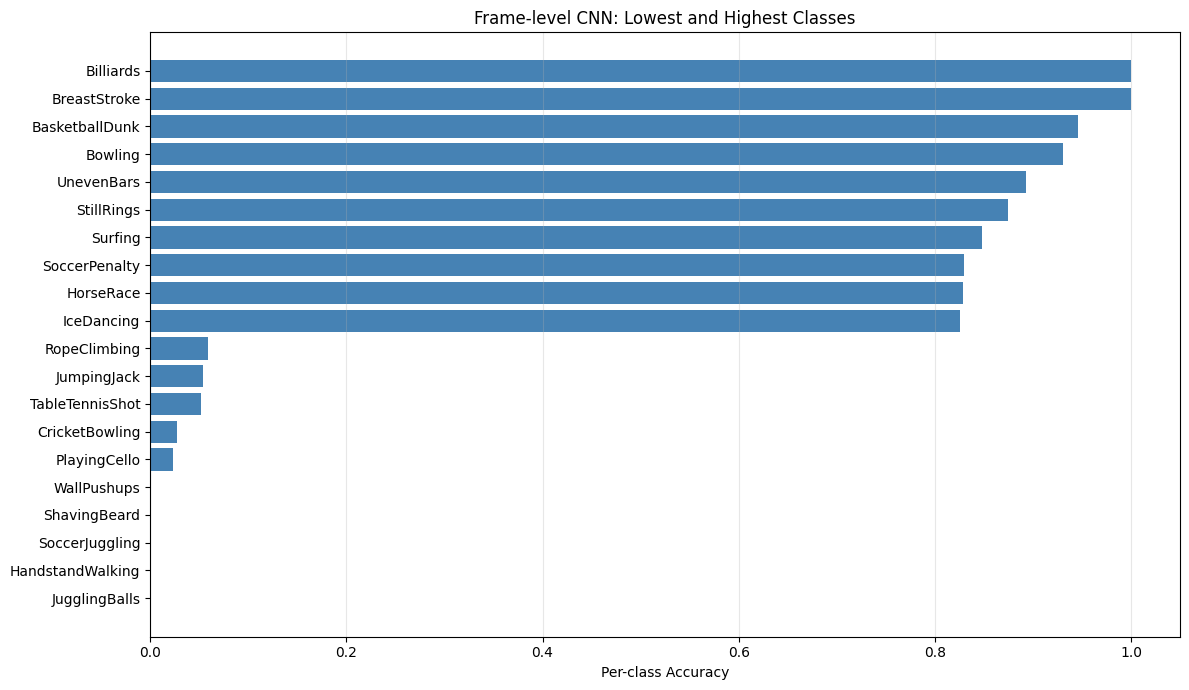

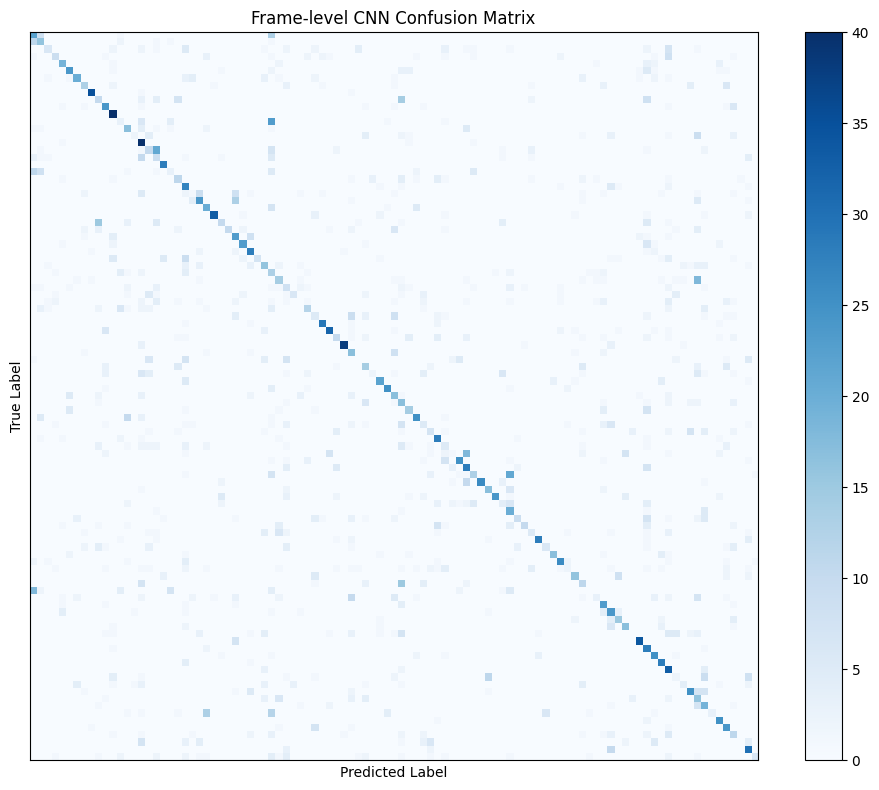

In [19]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions, labels=np.arange(len(selected_classes)))

# Find the worst and best classes
valid_indices = np.where(~np.isnan(frame_eval_per_class_acc))[0]
summary_indices = valid_indices[np.argsort(frame_eval_per_class_acc[valid_indices])]
summary_indices = np.array(list(dict.fromkeys(
    np.concatenate([summary_indices[:10], summary_indices[-10:]]).tolist()
)))

print(f"{'Class':<30} {'Accuracy':>10}")
print("-" * 43)
for idx in summary_indices:
    print(f"{selected_classes[idx]:<30} {frame_eval_per_class_acc[idx]:>10.4f}")

# Training curve
epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"],   marker="o", label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Frame-level CNN Loss"); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train Acc")
plt.plot(epochs, history["val_acc"],   marker="o", label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Frame-level CNN Accuracy"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Per-class accuracy
plot_classes = [selected_classes[i] for i in summary_indices]
plot_acc     = frame_eval_per_class_acc[summary_indices]
plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(plot_classes, plot_acc, color="steelblue")
plt.xlabel("Per-class Accuracy"); plt.title("Frame-level CNN: Lowest and Highest Classes")
plt.xlim(0, 1.05); plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

# Confusion Matrix Visualization
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Frame-level CNN Confusion Matrix"); plt.colorbar()
plt.xticks([]); plt.yticks([])
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.tight_layout(); plt.show()

In [20]:
%cd /content/video-action-recognition

# 先保存当前notebook到仓库目录
import shutil
shutil.copy("/content/ActionRecognition_GPU.ipynb",
            "/content/video-action-recognition/ActionRecognition_GPU.ipynb")

!git add ActionRecognition_GPU.ipynb
!git commit -m "add GPU version notebook: FrameLevelCNN trained, test acc 43.11%"
!git push origin frank/multimodal-extension

/content/video-action-recognition


FileNotFoundError: [Errno 2] No such file or directory: '/content/ActionRecognition_GPU.ipynb'

In [21]:
import subprocess
result = subprocess.run(['find', '/content', '-name', '*.ipynb'],
                      capture_output=True, text=True)
print(result.stdout)

/content/drive/MyDrive/ML_Project/ActionRecognition_GPU.ipynb
/content/drive/MyDrive/ML_Project/Action.ipynb
/content/drive/MyDrive/Colab Notebooks/WPO1/Practical_session_1_Draft.ipynb
/content/drive/MyDrive/Colab Notebooks/WPO2/DAHCC, Practical session 2.ipynb
/content/drive/MyDrive/Colab Notebooks/WPO3/DAHCC, Practical session 3.ipynb
/content/drive/MyDrive/Colab Notebooks/WPO4/DAHCC, Practical session 4.ipynb
/content/drive/MyDrive/Colab Notebooks/WPO5/Practical_session_5_student_2026.ipynb
/content/drive/MyDrive/Colab Notebooks/WPO6/Practical_session_6_student.ipynb
/content/drive/MyDrive/Google AI Studio/Analyse (5).ipynb
/content/drive/MyDrive/Google AI Studio/Analyse (4).ipynb
/content/drive/MyDrive/Google AI Studio/Analyse (3).ipynb
/content/drive/MyDrive/Google AI Studio/Analyse (2).ipynb
/content/drive/MyDrive/Google AI Studio/Analyse (1).ipynb
/content/drive/MyDrive/Google AI Studio/Analyse.ipynb
/content/drive/MyDrive/Machine Learning Lab/Lab 1/Exercices/ex1_simple_linear_r